In [1]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
import matplotlib.pyplot as plt

In [2]:
train = pd.read_csv("DailyDelhiClimateTrain.csv")
train["date"] = pd.to_datetime(train["date"])
test = pd.read_csv("DailyDelhiClimateTest.csv")
test["date"] = pd.to_datetime(test["date"])

In [4]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1462 entries, 0 to 1461
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   date          1462 non-null   datetime64[ns]
 1   meantemp      1462 non-null   float64       
 2   humidity      1462 non-null   float64       
 3   wind_speed    1462 non-null   float64       
 4   meanpressure  1462 non-null   float64       
dtypes: datetime64[ns](1), float64(4)
memory usage: 57.2 KB


In [5]:
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 114 entries, 0 to 113
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   date          114 non-null    datetime64[ns]
 1   meantemp      114 non-null    float64       
 2   humidity      114 non-null    float64       
 3   wind_speed    114 non-null    float64       
 4   meanpressure  114 non-null    float64       
dtypes: datetime64[ns](1), float64(4)
memory usage: 4.6 KB


In [6]:
for df in [train, test]:
    df["year"] = df["date"].dt.year
    df["month"] = df["date"].dt.month
    df["day"] = df["date"].dt.day
    df["day_of_week"] = df["date"].dt.dayofweek
    df["quarter"] = df["date"].dt.quarter

In [7]:
features = [
    "humidity",
    "wind_speed",
    "meanpressure",
    "year",
    "month",
    "day",
    "day_of_week",
    "quarter"
]
X_train = train[features]
y_train = train["meantemp"]

X_test = test[features]
y_test = test["meantemp"]

In [9]:
lr = LinearRegression()
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)

In [10]:
rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

In [11]:
def evaluate(actual, predicted):
    mae = mean_absolute_error(actual, predicted)
    mse = mean_squared_error(actual, predicted)
    rmse = np.sqrt(mse)
    r2 = r2_score(actual, predicted)
    return mae, rmse, r2
lr_result = evaluate(y_test, lr_pred)
rf_result = evaluate(y_test, rf_pred)

print("Linear Regression")
print("MAE :", lr_result[0])
print("RMSE:", lr_result[1])
print("R² :", lr_result[2])

print()

print("Random Forest")
print("MAE :", rf_result[0])
print("RMSE:", rf_result[1])
print("R² :", rf_result[2])

Linear Regression
MAE : 4.774366000122661
RMSE: 5.678645571440847
R² : 0.19574847904256565

Random Forest
MAE : 2.5972591946679873
RMSE: 3.291784928175357
R² : 0.7297502698018131


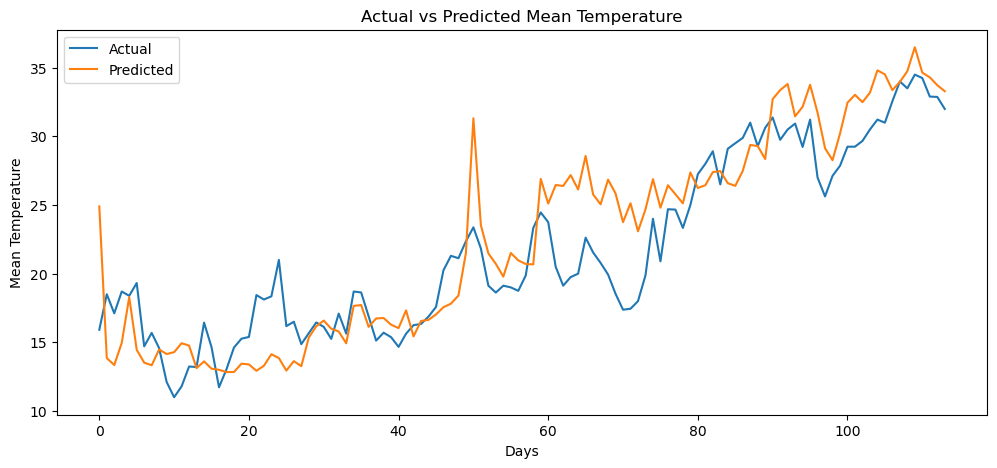

In [12]:
plt.figure(figsize=(12,5))
plt.plot(y_test.values, label="Actual")
plt.plot(rf_pred, label="Predicted")
plt.title("Actual vs Predicted Mean Temperature")
plt.xlabel("Days")
plt.ylabel("Mean Temperature")
plt.legend()
plt.show()

In [13]:
result = test.copy()
result["Predicted_Temperature"] = rf_pred
result.to_csv(
    "Temperature_Predictions.csv",
    index=False
)